In [12]:
# 1) Make sure the CRAN-installed one isn’t attached
if ("package:exdqlm" %in% search()) detach("package:exdqlm", unload = TRUE)

# 2) Load your local repo build (this compiles/loads the source in /home/antonio/code/exdqlm)
install.packages("devtools")        # if needed, once
devtools::load_all("/home/antonio/code/exdqlm")
# You should see: Loading exdqlm

# 3) Verify we’re using the local one
getFromNamespace("exdqlmISVB", "exdqlm")  # should point to your modified function


Installing package into ‘/home/antonio/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



ℹ Loading exdqlm


function(y, p0, model, df, dim.df,
                       fix.gamma = FALSE, gam.init = NA,
                       fix.sigma = TRUE, sig.init = NA,
                       dqlm.ind = FALSE,
                       exps0,
                       tol = 0.1,
                       n.IS = 500,
                       n.samp = 200,
                       PriorSigma = NULL,
                       PriorGamma = NULL,
                       verbose = TRUE,
                       debug_shapes = FALSE,    
                       debug_every = 5) {       

  # check inputs
  y = check_ts(y)
  model = check_mod(model)
  rv = check_logics(gam.init,sig.init,fix.gamma,fix.sigma,dqlm.ind)
  gam.init = rv$gam.init
  dqlm.int = rv$dqlm.ind
  fix.gamma = rv$fix.gamma

  ### Define L and U
  L = L.fn(p0); U = U.fn(p0)
  if(!is.na(gam.init)){
    if(gam.init < L | gam.init > U){
      stop(sprintf("gam.init must be between %s and %s for %s quantile",round(L,3),round(U,3),p0))
    }
  }

  ### sigma and gamma priors
  # sigma ~ IG(a_sig,b_sig)
  if(is.null(PriorSigma)){
    m_sigma = 1
    v_sigma = 10
    PriorSigma$a_sig = (m_sigma^2)/(v_sigma) + 2
    PriorSigma$b_sig = (m_sigma^3)/(v_sigma) + m_sigma
  }else{
    if(!is.list(PriorSigma) | any( is.na( match(c("a_sig", "b_sig"),names(PriorSigma)) ) )){
      stop("`PriorSigma` must be a list containing `a_sig` and `b_sig`")
      }
  }
  # gamma ~ truncated student t on L,U
  if(is.null(PriorGamma)){
    PriorGamma$m_gam = 0
    PriorGamma$s_gam = 1
    PriorGamma$df_gam = 1
   }else{
     if(!is.list(PriorGamma) | any( is.na( match(c("m_gam", "s_gam", "df_gam"),names(PriorGamma)) ) )){
       stop("`PriorGamma` must be a list containing `m_gam`,`s_gam`, and `df_gam`")
     }
   }
  PriorGammaDens<-function(gamma){ crch::dtt(gamma,location = PriorGamma$m_gam, scale = PriorGamma$s_gam, df = PriorGamma$df_gam, left = L, right = U, log = FALSE) }

  ### state-space model
  ## prior, theta ~ N(m0,C0)
  m0 = model$m0
  C0 = model$C0
  #
  TT = length(y)
  p = length(m0)
  if(!is.na(dim(model$GG)[3])){
    if(dim(model$GG)[3] != TT){stop("time-varying dimension of GG does not match length of y")}
  }
  GG = array(model$GG,c(p,p,TT)); model$GG = GG
  if(ncol(model$FF)>1){
    if(ncol(model$FF) != TT){stop("time-varying dimension of FF does not match length of y")}
  }
  FF = matrix(model$FF,p,TT); model$FF = FF
  ## discount factor blocking
  if(!methods::hasArg(dim.df)){
    if(length(df)!=1){
      stop("length of component discount factors does not match length of component dimensions")
    }
    dim.df = p
  }
  df.mat = make_df_mat(df,dim.df,p)

  ### Initialize VB
  gam0 = ifelse(!is.na(gam.init),gam.init,(L+U)/2)
  sig0 = ifelse(!is.na(sig.init),sig.init,1)
  new.gamsig.out = list(E.gam=gam0,V.gam=10,
                        E.sigma=ifelse(!is.na(sig0),sig0,m_sigma),V.sig=10,
                        E.inv.sigma=ifelse(!is.na(sig0),1/sig0,1/m_sigma),
                        E.c2.invb.absgam2.sigma = sig0*(C.fn(p0,gam0)^2)*(abs(gam0)^2)/B.fn(p0,gam0),
                        E.c.invb.absgam = C.fn(p0,gam0)*abs(gam0)/B.fn(p0,gam0),
                        E.c.a.invb.absgam = C.fn(p0,gam0)*A.fn(p0,gam0)*abs(gam0)/B.fn(p0,gam0),
                        E.a2.invb.inv.sigma = (A.fn(p0,gam0)^2)/(B.fn(p0,gam0)*sig0),
                        E.invb.inv.sigma = 1/(sig0*B.fn(p0,gam0)),
                        E.a.invb.inv.sigma = A.fn(p0,gam0)/(B.fn(p0,gam0)*sig0))
  new.sts.out = list(E.sts=rep(truncnorm::etruncnorm(a=0,b=Inf,mean=1,sd=1),TT),
                     E.sts2=rep(truncnorm::etruncnorm(a=0,b=Inf,mean=1,sd=1)^2+truncnorm::vtruncnorm(a=0,b=Inf,mean=1,sd=1),TT))
  new.uts.out = list(E.uts=rep(1/sig0,TT),
                     E.inv.uts=rep(sig0,TT))
  if(methods::hasArg(exps0)){
    if(length(exps0) != TT){ stop("exps0 must have same length as y") }
  }else{
    init.dlm = dlm_df(y,model,df,dim.df,s.priors=list(l0=1,S0=sig0),just.lik=FALSE)
    exps0 = apply(FF*t(init.dlm$m),2,sum) + stats::qnorm(p0,0,sqr

In [13]:
# Data
data("BTflow", package = "exdqlm")
data("nino34", package = "exdqlm")
# Components
trend.comp <- polytrendMod(order = 3, m0 = rep(0,3), C0 = diag(3))
seas.comp  <- seasMod(p = 12, h = 1, C0 = diag(1, 2))
base.mod   <- combineMods(trend.comp, seas.comp)
# Setting up regression component
reg.comp <- list(m0 = 0, C0 = 1, FF = matrix(nino34, nrow = 1), GG = 1)
model.w.reg <- combineMods(base.mod, reg.comp)


In [14]:
model.w.reg$FF
model.w.reg$GG

1.0,1.0,1.00,1.00,1.00,1.0,1.00,1.0,1.00,1.0,⋯,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1.0,1.0,1.00,1.00,1.00,1.0,1.00,1.0,1.00,1.0,⋯,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
-0.3,0.3,0.25,0.21,-0.43,-0.3,0.09,-0.2,0.17,-0.1,⋯,-0.04,-0.42,-0.66,-1.19,-1.01,-0.98,-1.04,-0.94,-0.72,-0.55


1,1,0,0.0000000,0.0000000,0
0,1,1,0.0000000,0.0000000,0
0,0,1,0.0000000,0.0000000,0
0,0,0,0.8660254,0.5000000,0
0,0,0,-0.5000000,0.8660254,0
0,0,0,0.0000000,0.0000000,1


In [25]:
# Same X you used for TF
X <- cbind(nino34, nino34^2, nino34^3)  # T x n
reg.comp  <- regMod(X)                  # FF: n x T, GG: n x n (I_n)
model.std <- combineMods(base.mod, reg.comp)


In [26]:
Tlen <- nrow(X); n <- ncol(X)
p_base <- length(base.mod$m0)                 # state dim of base.mod
p_std  <- length(model.std$m0)                # should be p_base + n

# FF should be (p_base + n) x T
stopifnot(identical(dim(model.std$FF), c(p_std, Tlen)))

# GG should be (p_base + n) x (p_base + n) **matrix** (static coefficients → no 3rd dim)
stopifnot(is.matrix(model.std$GG),
          identical(dim(model.std$GG), c(p_std, p_std)))


In [27]:
t <- 666L
Ft <- model.std$FF[, t]

# The last n entries of F_t must equal X[t, ] (standard DLM regression: F_t = X_t)
Ft_reg_part <- tail(Ft, n)
stopifnot(all.equal(as.numeric(Ft_reg_part), as.numeric(X[t, ]), tolerance = 1e-12))

# The regression block of GG must be I_n (static β); extract bottom-right block
idx_reg <- (p_base + 1):(p_base + n)
G_reg_block <- model.std$GG[idx_reg, idx_reg]
stopifnot(all.equal(G_reg_block, diag(n)))


In [28]:
model.std$FF[, 666]           # should end with X[666, ]
model.std$GG[idx_reg, idx_reg]# should be I_n


[1] 1.000000 0.000000 0.000000 1.000000 0.000000 0.530000 0.280900 0.148877

1,0,0
0,1,0
0,0,1


### Testing fit 
- Multiple linear regression - tf + LDVB

In [46]:
devtools::load_all()

# --- Data --------------------------------------------------------------------
data("BTflow", package = "exdqlm")
data("nino34", package = "exdqlm")
y <- BTflow
X <- cbind(nino34, nino34^2, nino34^3)

# --- Base components: trend + seasonal with harmonics 1:6 --------------------
p <- 12
harmonics <- 1:6

# seasonal state dimension:
# if max(h * 2π / p) == π (true when p is even and h includes p/2), seas_dim = 2*nh - 1
# otherwise seas_dim = 2*nh
nh <- length(harmonics)
seas_dim <- if (max(harmonics * 2 * pi / p) == pi) 2 * nh - 1L else 2 * nh

trend.comp <- polytrendMod(order = 1, m0 = 0, C0 = 1)          # 1-dim trend
seas.comp  <- seasMod(p = p, h = harmonics, C0 = diag(1, seas_dim))
base.mod   <- combineMods(trend.comp, seas.comp)

# Discount factors: one block per component (trend:1, season:seas_dim)
df_base     <- c(1.0, 0.99999999)
dim.df_base <- c(1L, seas_dim)

# --- Fit TF exDQLM with LDVB -------------------------------------------------
fit <- transfn_exdqlmLDVB(
  y, p0 = 0.5, model = base.mod,
  X = X,
  df = df_base, dim.df = dim.df_base,
  lambda = 0.99,                # or a length-T vector
  tf.df  = c(0.99999999, 0.99999999),     # (accumulator, all betas)
  gam.init = 0,  sig.init = 1,
  tol = 0.05, n.samp = 300
)

# --- (Optional) sanity checks ------------------------------------------------
p_base <- length(base.mod$m0)                         # = 1 + seas_dim
nreg   <- ncol(X)
stopifnot(
  sum(dim.df_base) == p_base,
  isTRUE(all.equal(dim(fit$model$FF), c(p_base + nreg + 1L, nrow(X)))),
  isTRUE(all.equal(dim(fit$model$GG),
                   c(p_base + nreg + 1L, p_base + nreg + 1L, nrow(X))))
)


ℹ Loading exdqlm
LDVB start | T=1012, p=16, tol=0.05 | KF:C++ | ELBO:on

iter   5 | maxDelta=62.9 | sigma=58.6 | gamma=-0.0948 | ELBO=8258.031211 (Delta=-1.66e+03)

iter  10 | maxDelta=3.82 | sigma=41.2 | gamma=-0.283 | ELBO=7604.119459 (Delta=6.24e+01)

iter  15 | maxDelta=0.766 | sigma=39 | gamma=-0.325 | ELBO=7712.065597 (Delta=6.47e+00)

iter  20 | maxDelta=0.123 | sigma=38.7 | gamma=-0.332 | ELBO=7721.022315 (Delta=5.28e-01)



LDVB converged: 22 iterations, 27.371 seconds 


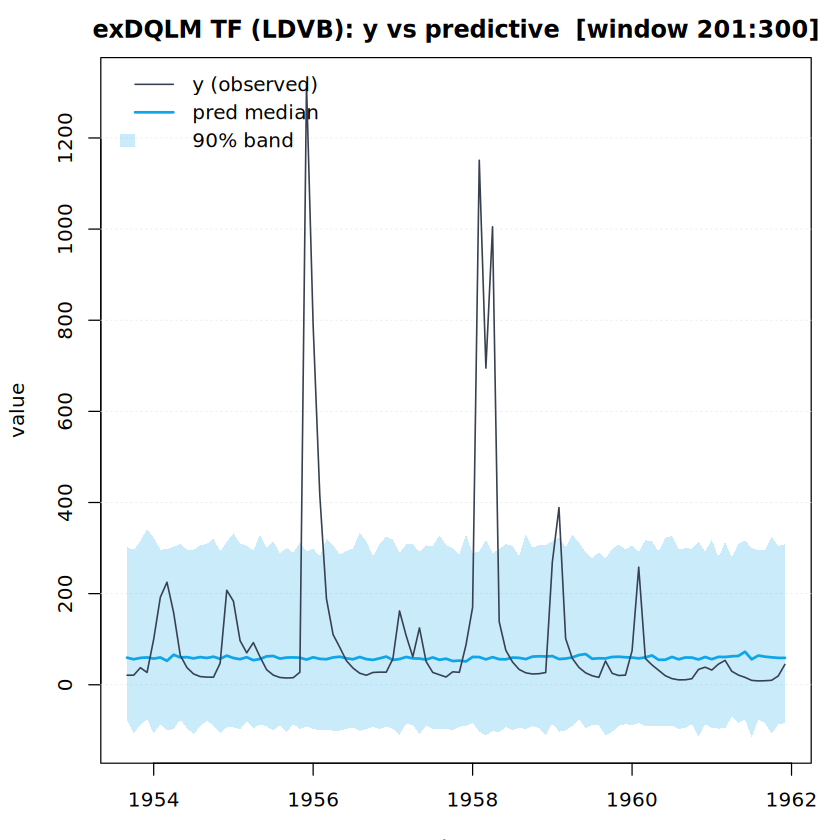

In [48]:
## --- posterior predictive summary ------------------------------------------
.get_FF_T <- function(FF, Tlen) {
  if (is.null(dim(FF))) FF <- matrix(FF, ncol = 1L)
  if (ncol(FF) == 1L) matrix(FF, nrow(FF), Tlen) else FF
}

pp_summary <- function(fit) {
  if (!is.null(fit$samp.post.pred)) {
    S <- fit$samp.post.pred
    list(
      med = apply(S, 2, stats::median),
      lo  = apply(S, 2, stats::quantile, probs = 0.05),
      hi  = apply(S, 2, stats::quantile, probs = 0.95),
      via = "postpred"
    )
  } else {
    sm <- fit$theta.out$sm
    FF <- .get_FF_T(fit$model$FF, ncol(sm))
    mu <- colSums(FF * sm)
    list(med = mu, lo = mu, hi = mu, via = "location")
  }
}

pp <- pp_summary(fit)

## --- pick the window -------------------------------------------------------
# Option A: last N points
win <- 100L
Tlen <- min(length(y), length(pp$med))
i2 <- Tlen
i1 <- max(1L, i2 - win + 1L)

# Option B: explicit range (uncomment to use)
# i1 <- 400L; i2 <- 700L

## --- slice to window --------------------------------------------------------
idx  <- i1:i2
xaxs <- if (is.ts(y)) time(y)[idx] else idx
y_w  <- as.numeric(y)[idx]
med  <- pp$med[idx]
lo   <- pp$lo[idx]
hi   <- pp$hi[idx]

## --- colors (high contrast) -------------------------------------------------
col_y    <- "#374151"  # dark gray
col_med  <- "#0EA5E9"  # blue
col_band <- grDevices::adjustcolor("#0EA5E9", alpha.f = 0.22)
col_grid <- "#E5E7EB"  # light gray

## --- plot window only -------------------------------------------------------
ylim <- range(c(y_w, lo, hi), finite = TRUE)

op <- par(no.readonly = TRUE); par(mar = c(3.2, 4.2, 2.4, 1.2))

plot(xaxs, y_w, type = "n", xlab = "time", ylab = "value",
     main = sprintf("exDQLM TF (LDVB): y vs predictive  [window %d:%d]", i1, i2),
     ylim = ylim)

# light horizontal grid
abline(h = axTicks(2), col = col_grid, lty = 3, lwd = 0.7)

# 90% predictive band (window only) — skip if band is degenerate
if (!all(lo == hi)) {
  polygon(c(xaxs, rev(xaxs)), c(lo, rev(hi)), col = col_band, border = NA)
}

# predictive median (window only)
lines(xaxs, med, lwd = 2.2, col = col_med)

# observed y (window only)
lines(xaxs, y_w, lwd = 1.3, col = col_y)

legend("topleft",
       legend = c("y (observed)", "pred median", "90% band"),
       col    = c(col_y, col_med, NA),
       lwd    = c(1.3, 2.2, NA),
       fill   = c(NA, NA, if (all(lo == hi)) NA else col_band),
       border = NA,
       bty    = "n", y.intersp = 1.1, seg.len = 2)

par(op)


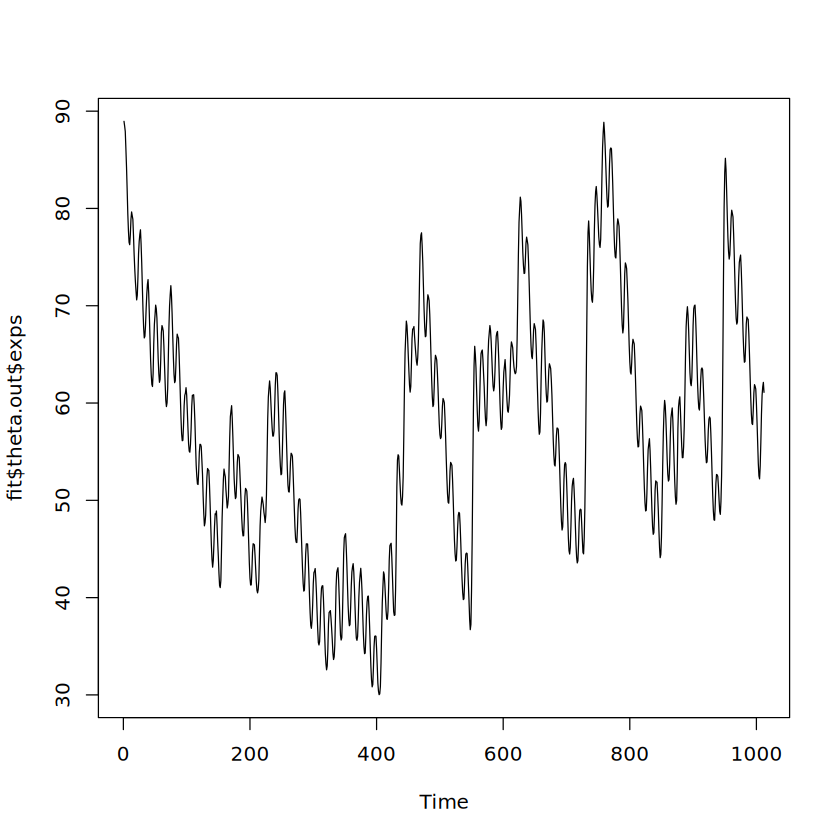

In [60]:
plot.ts(fit$theta.out$exps)
lines(y, col = "red")